# LIBRARY

In [1]:
import pickle
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely.geometry as sgeom
import xarray as xr
from scipy.ndimage import uniform_filter
from scipy.sparse.linalg import svds

import time
import numpy as np
import xarray as xr

try:
    from scipy import ndimage
    from scipy.sparse.linalg import svds
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

import os
import pickle

# LOAD DATA

In [2]:
# dataset hasil masking
ds_wpp572 = xr.open_dataset("/kaggle/input/notebooks/andreh19/2-masking/ds_wpp572.nc")
ds_wpp572

<xarray.Dataset> Size: 356MB
Dimensions:  (time: 505, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat      (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon      (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (time, lat, lon) float32 356MB ...
    palette  (time, rgb, eightbitcolor) uint8 388kB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

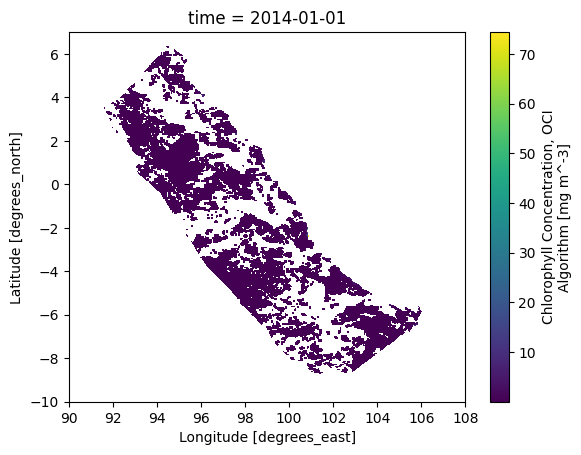

In [3]:
ds_wpp572['chlor_a'].isel(time=0).plot()
plt.show()

In [4]:
# masking koordinat
with np.load('/kaggle/input/notebooks/andreh19/2-masking/mask_wpp572.npz') as data:
    mask_2d = data['mask_2d']
    lons = data['lons']
    lats = data['lats']

mask_2d

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(408, 432))

In [5]:
inside_mask = mask_2d == True # area WPP572
n_pixels= inside_mask.sum() # jumlah pasangan titik
print("Jumlah pasangan titik yang ada di dalam area WPP 572:", n_pixels)

Jumlah pasangan titik yang ada di dalam area WPP 572: 44054


In [6]:
chl = ds_wpp572['chlor_a'].values
chl_inside = chl[:, mask_2d]  # chl sebelum mengisi missing value
times = ds_wpp572['time'].values

# Cek Missing Value

In [7]:
# hitung jumlah valid, jumlah missing dan presentasi missing per week
total_valid = []
total_missing = []
percent_missing = []

for t in range(chl.shape[0]):
    data_t = chl[t][inside_mask]  # hanya piksel di WPP 572
    n_missing = np.isnan(data_t).sum()
    n_valid = np.isfinite(data_t).sum()
    
    total_valid.append(n_valid)
    total_missing.append(n_missing)
    percent_missing.append(n_missing / n_pixels * 100)

In [8]:
# week 1 (2014-01-01)
print(total_valid[0])
print(total_missing[0])
print(total_valid[0]+total_missing[0])

25817
18237
44054


In [9]:
# simpan ke dalam dataset untuk missvalnya
df_missval = pd.DataFrame({
    "week_index": range(1, ds_wpp572.sizes["time"] + 1),
    'time': times,
    'total_valid': total_valid,
    'total_missing': total_missing,
    'percent_missing': percent_missing
})

df_missval.head(10)

,week_index,time,total_valid,total_missing,percent_missing
0,1,2014-01-01,25817,18237,41.396922
1,2,2014-01-09,16167,27887,63.301857
2,3,2014-01-17,12176,31878,72.361193
3,4,2014-01-25,35208,8846,20.079902
4,5,2014-02-02,19158,24896,56.512462
5,6,2014-02-10,35641,8413,19.097017
6,7,2014-02-18,27205,16849,38.246243
7,8,2014-02-26,37529,6525,14.811368
8,9,2014-03-06,19180,24874,56.462523
9,10,2014-03-14,16889,27165,61.662959


# EDA (1)
sebelum handling missing value

In [10]:
# deskripsi data

# Ambil hanya nilai valid (hapus NaN)
chl_valid = chl_inside[np.isfinite(chl_inside)]

mean_val = np.mean(chl_valid)
min_val = np.min(chl_valid)
max_val = np.max(chl_valid)
range_val = max_val - min_val
q1 = np.percentile(chl_valid, 25)
median = np.percentile(chl_valid, 50)
q3 = np.percentile(chl_valid, 75)

df_desc_before = pd.DataFrame({
    'Statistik': [
        'Rata-rata',
        'Minimum',
        'Maximum',
        'Range',
        '25%',
        'Median',
        '75%'],
    'Value': [
        mean_val,
        min_val,
        max_val,
        range_val,
        q1,
        median,
        q3]
})

df_desc_before.T

,0,1,2,3,4,5,6
Statistik,Rata-rata,Minimum,Maximum,Range,25%,Median,75%
Value,0.215953,0.01303,85.861519,85.848488,0.086027,0.117421,0.177097


### CHL Valid 

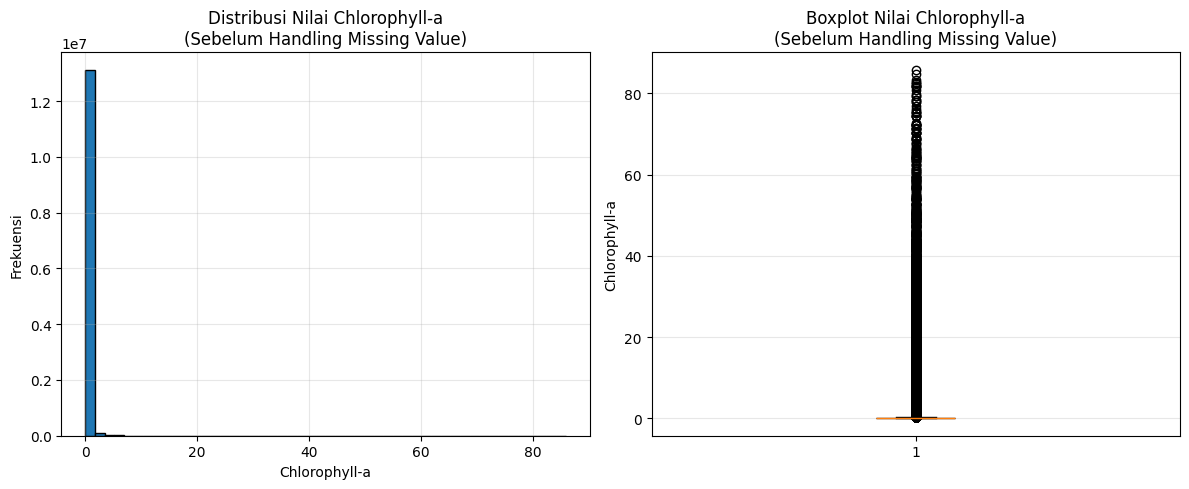

In [11]:
# Distribusi
plt.figure(figsize=(12,5))

# Kolom 1: Histogram
plt.subplot(1,2,1)
plt.hist(chl_valid, bins=50, edgecolor='black')
plt.title('Distribusi Nilai Chlorophyll-a\n(Sebelum Handling Missing Value)')
plt.xlabel('Chlorophyll-a')
plt.ylabel('Frekuensi')
plt.grid(alpha=0.3)

# Kolom 2: Boxplot
plt.subplot(1,2,2)
plt.boxplot(chl_valid, vert=True, patch_artist=True, showfliers=True)
plt.title('Boxplot Nilai Chlorophyll-a\n(Sebelum Handling Missing Value)')
plt.ylabel('Chlorophyll-a')
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

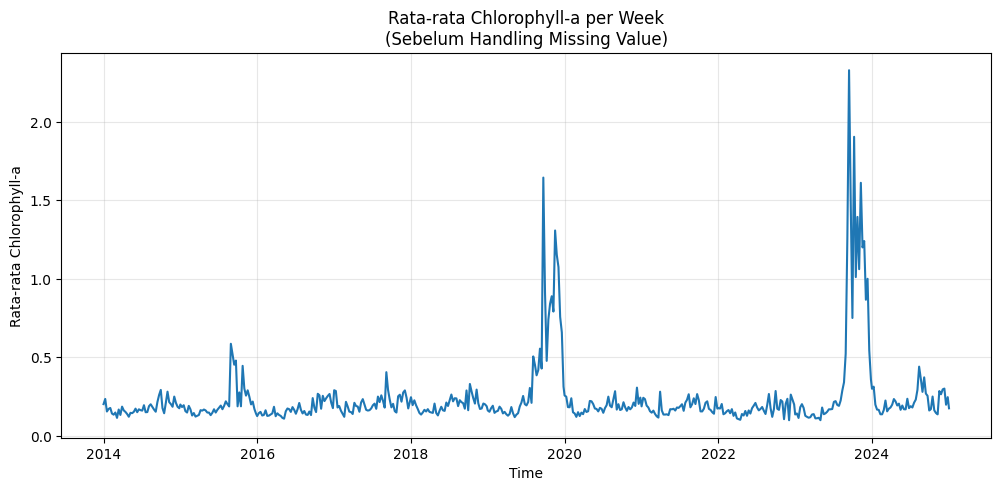

In [12]:
# line chart chl valid per week
mean_chl_weekly = np.nanmean(chl_inside, axis=1)

df_weekly_chl = pd.DataFrame({
    'time': times,
    'mean_chlor_a': mean_chl_weekly
})
plt.figure(figsize=(12,5))
plt.plot(
    df_weekly_chl['time'],
    df_weekly_chl['mean_chlor_a'],
    linewidth=1.5
)

plt.title('Rata-rata Chlorophyll-a per Week\n(Sebelum Handling Missing Value)')
plt.xlabel('Time')
plt.ylabel('Rata-rata Chlorophyll-a')
plt.grid(alpha=0.3)
plt.show()

### EDA Missval

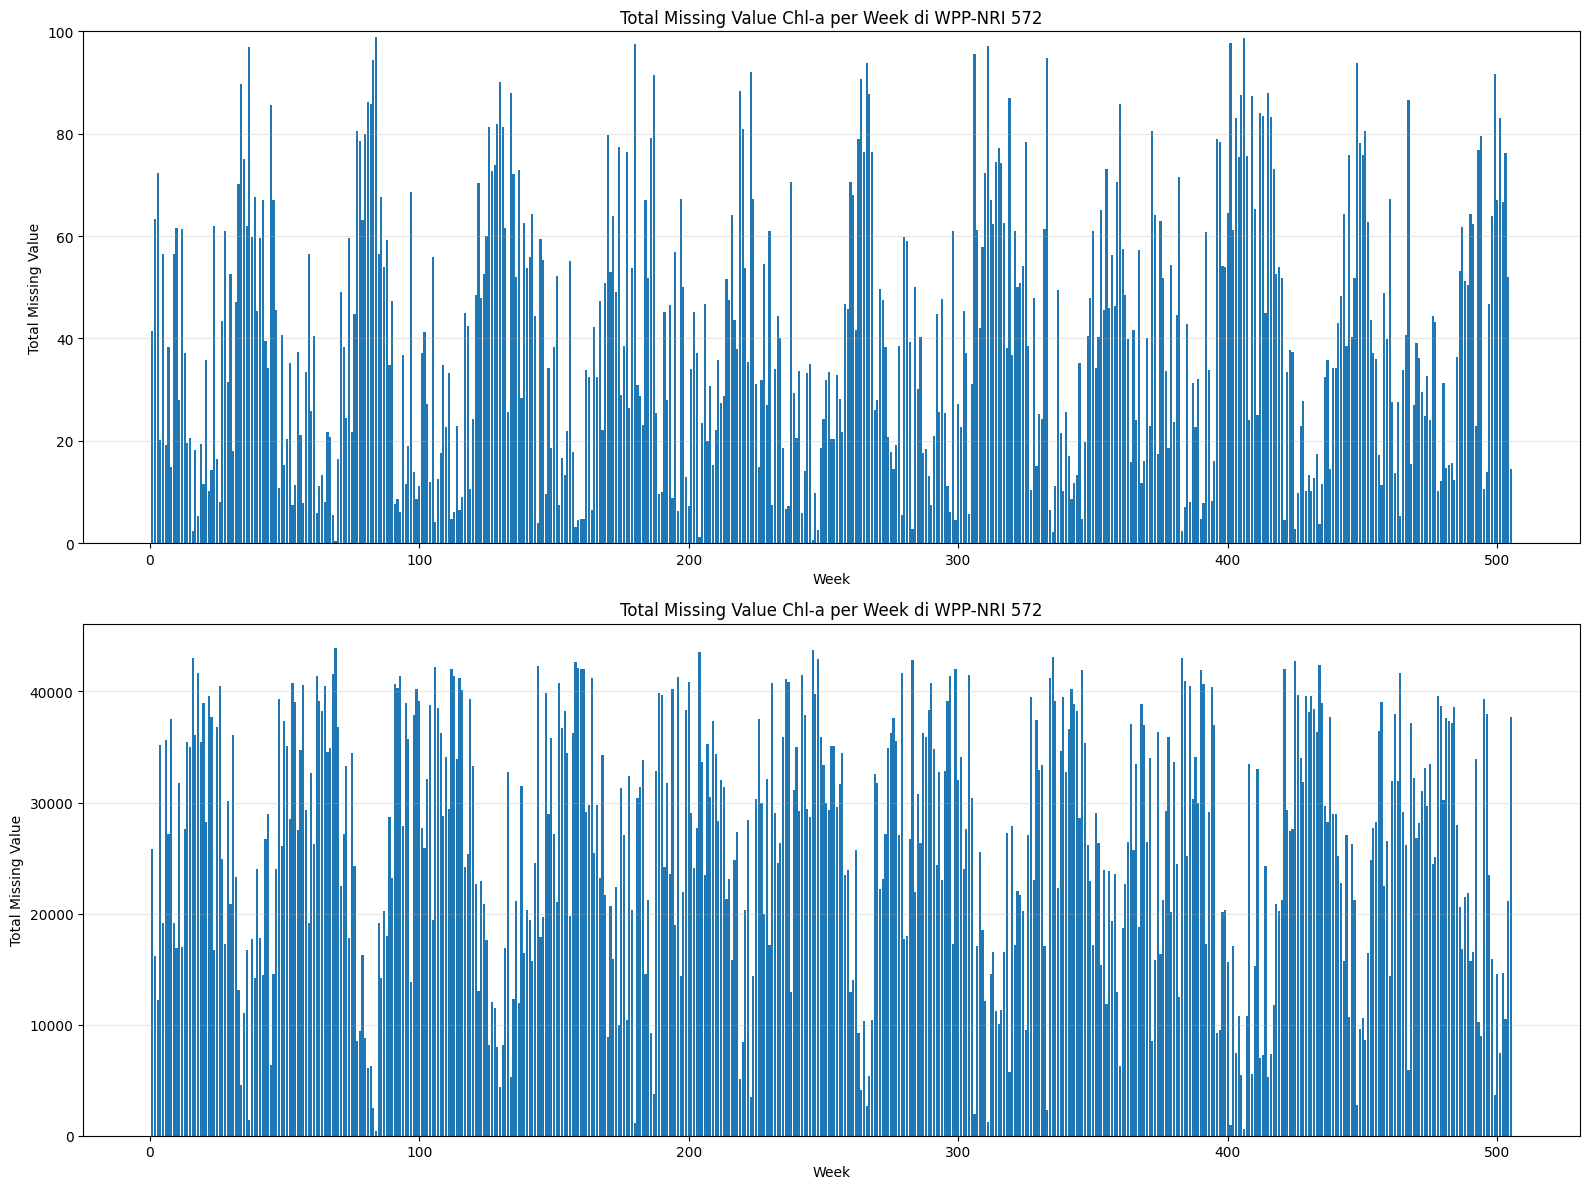

In [13]:
plt.figure(figsize=(16,12))

# Persentase Missing
plt.subplot(2,1,1)
plt.bar(
    df_missval['week_index'],
    df_missval["percent_missing"])
plt.title("Total Missing Value Chl-a per Week di WPP-NRI 572")
plt.xlabel("Week")
plt.ylabel("Total Missing Value")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)


# Total Valid 
plt.subplot(2,1,2)
plt.bar(
    df_missval['week_index'],
    df_missval["total_valid"])
plt.title("Total Missing Value Chl-a per Week di WPP-NRI 572")
plt.xlabel("Week")
plt.ylabel("Total Missing Value")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# DINEOF

In [14]:
ds_wpp572

<xarray.Dataset> Size: 356MB
Dimensions:  (time: 505, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat      (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon      (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (time, lat, lon) float32 356MB nan nan nan nan ... nan nan nan nan
    palette  (time, rgb, eightbitcolor) uint8 388kB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

## Outlier Handling

In [15]:
# chl_3d = ds_wpp572['chlor_a'].values
# time, lat, lon = chl_3d.shape
# mask_3d_wpp = np.broadcast_to(mask_2d, (time, lat, lon))

# # batas anomali
# batas_anomali = 2.983

# mask_anomali = (chl_3d > batas_anomali) & mask_3d_wpp
# jumlah_anomali = np.sum(mask_anomali)
# total_valid_wpp = np.sum((~np.isnan(chl_3d)) & mask_3d_wpp)
# persentase_anomali = (jumlah_anomali / total_valid_wpp) * 100

# # --- TAMPILKAN HASIL ---
# print(f"Jumlah pixel anomali (> {batas_anomali}) : {jumlah_anomali} pixel")
# print(f"Total pixel observasi valid di WPP : {total_valid_wpp} pixel")
# print(f"Presentase anomali = {persentase_anomali:.4f}%")

In [16]:
# outlier data dihapus jadi sekitar 0.5% data (outlier)
# ds_wpp572['chlor_a'] = ds_wpp572['chlor_a'].where(ds_wpp572['chlor_a'] <= batas_anomali)

## 3D DINEOF

In [17]:
import time as pytime

In [18]:
def run_3d_dineof(
    ds,
    var_name,
    modes=30,
    max_iter=50,
    tol=1e-5,
    verbose=True,
    log_every=1,
    cv_fraction=0.03,
    random_seed=42,
    mode_search=True,
    mode_patience=5,
    min_delta=0.0
):
    """
    Menjalankan 3D-DINEOF dengan pencarian mode optimal berbasis cross-validation.

    Alur utama:
    1. Membaca variabel 3D: time x lat x lon.
    2. Menggunakan mask_2d jika tersedia.
    3. Untuk chlor_a, data ditransformasi ke log10.
    4. Mengambil 3% data valid sebagai cross-validation.
    5. Menyembunyikan titik CV sebagai NaN.
    6. Menjalankan mode search dari 1 sampai modes.
    7. Memilih selected_mode berdasarkan CV_RMSE terkecil.
    8. Menjalankan final 3D-DINEOF pada data asli dengan selected_mode.
    9. Mengembalikan ds_hasil dan history.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset input.

    var_name : str
        Nama variabel, misalnya 'chlor_a'.

    modes : int
        Mode maksimum yang diuji. Jika modes=30, mode kandidat adalah 1 sampai 30.

    max_iter : int
        Maksimum iterasi internal setiap axis.

    tol : float
        Threshold konvergensi relatif.

    verbose : bool
        Jika True, menampilkan log progress.

    log_every : int
        Interval log iterasi.

    cv_fraction : float
        Fraksi cross-validation. Default 0.03 = 3%.

    random_seed : int
        Seed random untuk reprodusibilitas.

    mode_search : bool
        Jika True, mencari mode optimal dari 1 sampai modes.
        Jika False, langsung memakai fixed mode = modes.

    Returns
    -------
    ds_hasil : xarray.Dataset
        Dataset dengan variabel baru: f"{var_name}_3ddineof"

    history : dict
        Riwayat proses, mode search, CV RMSE, dan final run.
    """
    try:
        from scipy import ndimage
        from scipy.sparse.linalg import svds
        SCIPY_AVAILABLE = True
    except Exception:
        SCIPY_AVAILABLE = False

    def _log(message):
        if verbose:
            print(message, flush=True)

    start_total = pytime.time()

    # ------------------------------------------------------------
    # 1. Helper: deteksi dimensi
    # ------------------------------------------------------------
    def _find_dim(da, candidates):
        for c in candidates:
            if c in da.dims:
                return c
        raise ValueError(
            f"Tidak menemukan dimensi dari kandidat: {candidates}. "
            f"Dimensi tersedia: {da.dims}"
        )

    da = ds[var_name]

    if da.ndim != 3:
        raise ValueError(
            f"Variabel {var_name} harus 3D: time x lat x lon. "
            f"Saat ini ndim={da.ndim}, dims={da.dims}"
        )

    time_dim = _find_dim(da, ["time", "Time", "date", "day"])
    lat_dim = _find_dim(da, ["lat", "latitude", "Latitude", "y"])
    lon_dim = _find_dim(da, ["lon", "longitude", "Longitude", "x"])

    da_tyx = da.transpose(time_dim, lat_dim, lon_dim)
    data_full = da_tyx.values.astype("float64")

    ntime, nlat, nlon = data_full.shape

    # ------------------------------------------------------------
    # 2. Domain mask WPP
    # ------------------------------------------------------------
    if "mask_2d" in ds.variables:
        mask_da = ds["mask_2d"].transpose(lat_dim, lon_dim)
        mask_vals = np.asarray(mask_da.values)
        domain2d_full = np.where(np.isfinite(mask_vals), mask_vals, False).astype(bool)
        domain_source = "ds['mask_2d']"
    else:
        domain2d_full = np.isfinite(data_full).any(axis=0)
        domain_source = "inferred_from_any_valid_pixel"

    if domain2d_full.shape != (nlat, nlon):
        raise ValueError(
            f"Shape mask_2d {domain2d_full.shape} tidak sama dengan "
            f"shape spasial data {(nlat, nlon)}"
        )

    if domain2d_full.sum() == 0:
        raise ValueError("Domain mask kosong. Tidak ada piksel yang dapat direkonstruksi.")

    # Crop otomatis ke bounding box domain.
    iy, ix = np.where(domain2d_full)
    y_slice = slice(iy.min(), iy.max() + 1)
    x_slice = slice(ix.min(), ix.max() + 1)

    data = data_full[:, y_slice, x_slice]
    domain2d = domain2d_full[y_slice, x_slice]
    domain3d = np.broadcast_to(domain2d, data.shape)

    # ------------------------------------------------------------
    # 3. Transformasi data
    # ------------------------------------------------------------
    lower_name = var_name.lower()
    use_log10 = ("chl" in lower_name) or ("chlor" in lower_name)

    if use_log10:
        data = np.where(data > 0, data, np.nan)
        proc = np.where(np.isfinite(data), np.log10(data), np.nan)
        transform = "log10"
    else:
        proc = data.copy()
        transform = "linear"

    observed_mask = domain3d & np.isfinite(proc)
    target_missing_mask = domain3d & ~np.isfinite(proc)
    outside_mask = ~domain3d

    n_domain = int(domain3d.sum())
    n_observed = int(observed_mask.sum())
    n_missing = int(target_missing_mask.sum())
    missing_rate = n_missing / n_domain if n_domain > 0 else np.nan

    if n_observed == 0:
        raise ValueError("Tidak ada nilai valid di dalam domain. 3D-DINEOF tidak dapat dijalankan.")

    # ------------------------------------------------------------
    # 4. Cross-validation 3%
    # ------------------------------------------------------------
    rng = np.random.default_rng(random_seed)

    valid_indices = np.argwhere(observed_mask)
    n_valid_cv = len(valid_indices)
    n_cv = int(np.floor(cv_fraction * n_valid_cv))

    # Minimal 30 titik jika memungkinkan.
    if n_cv < 30:
        n_cv = min(30, n_valid_cv)

    if n_cv < 1:
        raise ValueError("Tidak ada cukup data valid untuk cross-validation.")

    selected = rng.choice(n_valid_cv, size=n_cv, replace=False)
    cv_indices = valid_indices[selected]

    cv_mask = np.zeros_like(observed_mask, dtype=bool)
    cv_mask[
        cv_indices[:, 0],
        cv_indices[:, 1],
        cv_indices[:, 2]
    ] = True

    cv_true_proc = proc[cv_mask].copy()

    # Data training untuk mode search.
    proc_cv = proc.copy()
    proc_cv[cv_mask] = np.nan

    _log("=" * 90)
    _log("[3D-DINEOF] MULAI PROSES")
    _log(f"Variabel                  : {var_name}")
    _log(f"Max mode kandidat         : 1 sampai {modes}")
    _log(f"Max iteration per axis    : {max_iter}")
    _log(f"Tolerance                 : {tol}")
    _log(f"Transform                 : {transform}")
    _log(f"CV fraction               : {cv_fraction * 100:.2f}%")
    _log(f"Jumlah titik CV           : {n_cv:,}")
    _log(f"Random seed               : {random_seed}")
    _log(f"Mode search               : {mode_search}")
    _log(f"Mode patience             : {mode_patience}")
    _log(f"Min delta RMSE            : {min_delta}")
    _log(f"Domain source             : {domain_source}")
    _log(f"Input shape full          : {data_full.shape}")
    _log(f"Working shape cropped     : {data.shape}")
    _log(f"Domain values 3D          : {n_domain:,}")
    _log(f"Observed values           : {n_observed:,}")
    _log(f"Target missing values     : {n_missing:,}")
    _log(f"Missing rate inside WPP   : {missing_rate * 100:.2f}%")
    _log("=" * 90)

    # ------------------------------------------------------------
    # 5. Helper: prefill 3D sliding-window
    # ------------------------------------------------------------
    def _prefill_3d_sliding_window(anom, domain3d, target_mask, max_prefill_iter=300):
        """
        Isi missing awal menggunakan mean 3x3x3.
        Hanya mengisi missing di dalam domain.
        """
        t0 = pytime.time()

        filled = anom.copy()
        filled[~domain3d] = 0.0

        prefill_history = []

        if SCIPY_AVAILABLE:
            kernel = np.ones((3, 3, 3), dtype="float64")

            for step in range(1, max_prefill_iter + 1):
                step_start = pytime.time()

                missing_now = target_mask & ~np.isfinite(filled)
                remaining_before = int(missing_now.sum())

                if remaining_before == 0:
                    break

                valid = domain3d & np.isfinite(filled)
                values = np.where(valid, filled, 0.0)

                weights = ndimage.convolve(
                    valid.astype("float64"),
                    kernel,
                    mode="constant",
                    cval=0.0
                )

                sums = ndimage.convolve(
                    values,
                    kernel,
                    mode="constant",
                    cval=0.0
                )

                can_fill = missing_now & (weights > 0)
                n_can_fill = int(can_fill.sum())

                if n_can_fill == 0:
                    break

                filled[can_fill] = sums[can_fill] / weights[can_fill]

                remaining_after = int((target_mask & ~np.isfinite(filled)).sum())
                step_elapsed = pytime.time() - step_start

                prefill_history.append({
                    "step": int(step),
                    "filled_this_step": int(n_can_fill),
                    "remaining_before": int(remaining_before),
                    "remaining_after": int(remaining_after),
                    "elapsed_sec": float(step_elapsed)
                })

                if verbose and step <= 5:
                    _log(
                        f"[PREFILL] step={step:3d} | "
                        f"filled={n_can_fill:,} | "
                        f"remaining={remaining_after:,} | "
                        f"time={step_elapsed:.2f}s"
                    )

                if remaining_after == 0:
                    break

        else:
            T, Y, X = filled.shape

            for step in range(1, max_prefill_iter + 1):
                step_start = pytime.time()

                missing_positions = np.argwhere(target_mask & ~np.isfinite(filled))
                remaining_before = len(missing_positions)

                if remaining_before == 0:
                    break

                filled_count = 0

                for t, y, x in missing_positions:
                    t0i, t1i = max(0, t - 1), min(T, t + 2)
                    y0i, y1i = max(0, y - 1), min(Y, y + 2)
                    x0i, x1i = max(0, x - 1), min(X, x + 2)

                    window = filled[t0i:t1i, y0i:y1i, x0i:x1i]
                    window_domain = domain3d[t0i:t1i, y0i:y1i, x0i:x1i]

                    vals = window[window_domain & np.isfinite(window)]

                    if vals.size > 0:
                        filled[t, y, x] = np.nanmean(vals)
                        filled_count += 1

                remaining_after = int((target_mask & ~np.isfinite(filled)).sum())
                step_elapsed = pytime.time() - step_start

                prefill_history.append({
                    "step": int(step),
                    "filled_this_step": int(filled_count),
                    "remaining_before": int(remaining_before),
                    "remaining_after": int(remaining_after),
                    "elapsed_sec": float(step_elapsed)
                })

                if verbose and step <= 5:
                    _log(
                        f"[PREFILL] step={step:3d} | "
                        f"filled={filled_count:,} | "
                        f"remaining={remaining_after:,} | "
                        f"time={step_elapsed:.2f}s"
                    )

                if filled_count == 0 or remaining_after == 0:
                    break

        still_missing = target_mask & ~np.isfinite(filled)
        fallback_count = int(still_missing.sum())

        # 0 anomaly berarti mean global pada skala transformasi.
        filled[still_missing] = 0.0
        filled[~domain3d] = 0.0

        elapsed = pytime.time() - t0

        return filled, {
            "method": "3x3x3_sliding_window",
            "history": prefill_history,
            "fallback_to_global_mean_anomaly_count": int(fallback_count),
            "elapsed_sec": float(elapsed)
        }

    # ------------------------------------------------------------
    # 6. Helper: SVD reconstruction
    # ------------------------------------------------------------
    def _svd_reconstruct(matrix, k):
        matrix = np.asarray(matrix, dtype="float64")

        m, n = matrix.shape
        rmax = min(m, n)

        if rmax <= 1:
            return matrix.copy()

        k = int(min(max(1, k), rmax))

        if SCIPY_AVAILABLE and k < rmax:
            try:
                U, S, Vt = svds(matrix, k=k)
                order = np.argsort(S)[::-1]
                U = U[:, order]
                S = S[order]
                Vt = Vt[order, :]
                return (U * S) @ Vt
            except Exception as e:
                _log(f"[WARNING] svds gagal, fallback ke np.linalg.svd. Error: {e}")

        U, S, Vt = np.linalg.svd(matrix, full_matrices=False)
        k = min(k, len(S))
        return (U[:, :k] * S[:k]) @ Vt[:k, :]

    # ------------------------------------------------------------
    # 7. Helper: DINEOF satu axis
    # ------------------------------------------------------------
    def _dineof_single_axis(filled3d, target_mask, axis, axis_name, mode_current):
        t_axis = pytime.time()

        moved = np.moveaxis(filled3d, axis, 0)
        moved_target = np.moveaxis(target_mask, axis, 0)

        original_shape = moved.shape
        M = moved.reshape(original_shape[0], -1)
        target_M = moved_target.reshape(original_shape[0], -1)

        n_target = int(target_M.sum())

        iter_history = []

        if n_target == 0:
            return filled3d, {
                "axis": axis_name,
                "mode": int(mode_current),
                "iterations": iter_history,
                "n_iterations": 0,
                "converged": True,
                "reason": "no_missing_target",
                "final_rmse_change": None,
                "final_relative_change": None,
                "elapsed_sec": pytime.time() - t_axis
            }

        converged = False
        reason = "max_iter_reached"

        for it in range(1, max_iter + 1):
            iter_start = pytime.time()

            old_values = M[target_M].copy()

            recon = _svd_reconstruct(M, mode_current)

            M_new = M.copy()
            M_new[target_M] = recon[target_M]

            new_values = M_new[target_M]
            diff = new_values - old_values

            rmse_change = float(np.sqrt(np.mean(diff ** 2)))

            denom = float(np.sqrt(np.mean(old_values ** 2)))
            if denom < 1e-12:
                denom = 1.0

            rel_change = rmse_change / denom
            iter_elapsed = pytime.time() - iter_start

            iter_history.append({
                "axis": axis_name,
                "mode": int(mode_current),
                "iteration": int(it),
                "rmse_change": float(rmse_change),
                "relative_change": float(rel_change),
                "elapsed_sec": float(iter_elapsed)
            })

            if verbose and ((it == 1) or (it % log_every == 0) or (rel_change < tol)):
                _log(
                    f"[{axis_name:9s}] "
                    f"mode={int(mode_current):3d} | "
                    f"iter={it:3d}/{max_iter} | "
                    f"RMSE_change={rmse_change:.8e} | "
                    f"rel_change={rel_change:.8e} | "
                    f"time={iter_elapsed:.2f}s"
                )

            M = M_new

            if rel_change < tol:
                converged = True
                reason = "tol_reached"
                break

        moved_out = M.reshape(original_shape)
        out = np.moveaxis(moved_out, 0, axis)

        elapsed_axis = pytime.time() - t_axis

        final_rmse_change = iter_history[-1]["rmse_change"] if iter_history else None
        final_relative_change = iter_history[-1]["relative_change"] if iter_history else None

        return out, {
            "axis": axis_name,
            "mode": int(mode_current),
            "iterations": iter_history,
            "n_iterations": len(iter_history),
            "converged": converged,
            "reason": reason,
            "final_rmse_change": final_rmse_change,
            "final_relative_change": final_relative_change,
            "elapsed_sec": float(elapsed_axis)
        }

    # ------------------------------------------------------------
    # 8. Core 3D-DINEOF untuk satu mode
    # ------------------------------------------------------------
    axis_sequence = [
        ("longitude", 2),
        ("latitude", 1),
        ("time", 0),
    ]

    def _run_3ddineof_core(proc_input, mode_current, label="core"):
        t_core = pytime.time()

        observed_mask_core = domain3d & np.isfinite(proc_input)
        target_missing_mask_core = domain3d & ~np.isfinite(proc_input)
        outside_mask_core = ~domain3d

        if int(observed_mask_core.sum()) == 0:
            raise ValueError(f"Tidak ada data valid untuk {label}")

        global_mean_core = np.nanmean(proc_input[observed_mask_core])
        anom_core = proc_input - global_mean_core

        _log("")
        _log("=" * 90)
        _log(f"[CORE START] {label} | mode={mode_current}")
        _log("=" * 90)

        filled, prefill_info = _prefill_3d_sliding_window(
            anom=anom_core,
            domain3d=domain3d,
            target_mask=target_missing_mask_core
        )

        filled[observed_mask_core] = anom_core[observed_mask_core]
        filled[outside_mask_core] = 0.0

        axis_history = []

        for stage_no, (axis_name, axis_id) in enumerate(axis_sequence, start=1):
            _log("")
            _log("-" * 90)
            _log(f"[{label}] STAGE {stage_no}/3 | AXIS={axis_name.upper()} | MODE={mode_current}")
            _log("-" * 90)

            before_axis = filled.copy()

            filled, h_axis = _dineof_single_axis(
                filled3d=filled,
                target_mask=target_missing_mask_core,
                axis=axis_id,
                axis_name=axis_name,
                mode_current=mode_current
            )

            # Kunci ulang data observasi dan luar domain.
            filled[observed_mask_core] = anom_core[observed_mask_core]
            filled[outside_mask_core] = 0.0

            axis_diff = filled[target_missing_mask_core] - before_axis[target_missing_mask_core]
            axis_rmse_change = (
                float(np.sqrt(np.mean(axis_diff ** 2)))
                if axis_diff.size > 0 else 0.0
            )

            h_axis["stage"] = int(stage_no)
            h_axis["axis_rmse_change_after_stage"] = float(axis_rmse_change)
            axis_history.append(h_axis)

            _log(
                f"[{label}] STAGE {stage_no}/3 DONE | "
                f"axis={axis_name.upper()} | "
                f"stage_RMSE_change={axis_rmse_change:.8e}"
            )

        recon_proc_core = filled + global_mean_core

        # Data observasi pada proc_input tetap dikunci.
        recon_proc_core[observed_mask_core] = proc_input[observed_mask_core]
        recon_proc_core[outside_mask_core] = np.nan

        elapsed_core = pytime.time() - t_core

        _log("")
        _log(f"[CORE DONE] {label} | mode={mode_current} | elapsed={elapsed_core:.2f}s")

        return recon_proc_core, {
            "label": label,
            "mode": int(mode_current),
            "global_mean": float(global_mean_core),
            "prefill": prefill_info,
            "axis_history": axis_history,
            "elapsed_sec": float(elapsed_core)
        }

    # ------------------------------------------------------------
    # 9. Mode search 1 sampai modes dengan CV 3% + patience
    # ------------------------------------------------------------
    mode_search_history = []
    
    mode_search_early_stopped = False
    mode_search_stop_reason = None
    stopped_at_mode = None
    no_improve_count = 0
    
    if mode_search:
        _log("")
        _log("=" * 90)
        _log("[MODE SEARCH] Mulai pencarian mode optimal")
        _log(f"Mode kandidat   : 1 sampai {modes}")
        _log(f"CV fraction     : {cv_fraction * 100:.2f}%")
        _log(f"Jumlah titik CV : {n_cv:,}")
        _log(f"Metric          : RMSE pada skala transformasi ({transform})")
        _log(f"Patience        : {mode_patience}")
        _log(f"Min delta       : {min_delta}")
        _log("=" * 90)
    
        best_mode = None
        best_rmse = np.inf
        best_mae = np.inf
        best_bias = np.nan
        best_corr = np.nan
        best_rmse_original = np.inf
    
        for mode_current in range(1, modes + 1):
            t_mode = pytime.time()
    
            _log("")
            _log("=" * 90)
            _log(f"[MODE SEARCH] Running mode {mode_current}/{modes}")
            _log("=" * 90)
    
            recon_cv_proc, h_cv = _run_3ddineof_core(
                proc_input=proc_cv,
                mode_current=mode_current,
                label=f"cv_mode_{mode_current}"
            )
    
            cv_pred_proc = recon_cv_proc[cv_mask]
            ok = np.isfinite(cv_true_proc) & np.isfinite(cv_pred_proc)
    
            if ok.sum() == 0:
                cv_rmse = np.nan
                cv_mae = np.nan
                cv_bias = np.nan
                cv_corr = np.nan
                cv_rmse_original = np.nan
            else:
                cv_rmse = float(np.sqrt(np.mean((cv_pred_proc[ok] - cv_true_proc[ok]) ** 2)))
                cv_mae = float(np.mean(np.abs(cv_pred_proc[ok] - cv_true_proc[ok])))
                cv_bias = float(np.mean(cv_pred_proc[ok] - cv_true_proc[ok]))
    
                if ok.sum() > 2:
                    cv_corr = float(np.corrcoef(cv_true_proc[ok], cv_pred_proc[ok])[0, 1])
                else:
                    cv_corr = np.nan
    
                # RMSE pada skala asli hanya sebagai laporan.
                if use_log10:
                    true_original = 10 ** cv_true_proc[ok]
                    pred_original = 10 ** cv_pred_proc[ok]
                else:
                    true_original = cv_true_proc[ok]
                    pred_original = cv_pred_proc[ok]
    
                cv_rmse_original = float(
                    np.sqrt(np.mean((pred_original - true_original) ** 2))
                )
    
            elapsed_mode = pytime.time() - t_mode
    
            # --------------------------------------------------------
            # Cek improvement RMSE
            # --------------------------------------------------------
            if np.isfinite(cv_rmse):
                improvement = best_rmse - cv_rmse
                is_improved = improvement > min_delta
            else:
                improvement = np.nan
                is_improved = False
    
            if is_improved:
                best_rmse = cv_rmse
                best_mae = cv_mae
                best_bias = cv_bias
                best_corr = cv_corr
                best_rmse_original = cv_rmse_original
                best_mode = int(mode_current)
                no_improve_count = 0
                improvement_status = "improved"
            else:
                no_improve_count += 1
                improvement_status = "no_improve"
    
            mode_row = {
                "mode": int(mode_current),
                "cv_rmse": cv_rmse,
                "cv_mae": cv_mae,
                "cv_bias": cv_bias,
                "cv_corr": cv_corr,
                "cv_rmse_original_scale": cv_rmse_original,
                "n_cv_used": int(ok.sum()),
                "elapsed_sec": float(elapsed_mode),
                "improvement": float(improvement) if np.isfinite(improvement) else None,
                "improvement_status": improvement_status,
                "no_improve_count": int(no_improve_count),
                "best_mode_so_far": int(best_mode) if best_mode is not None else None,
                "best_rmse_so_far": float(best_rmse) if np.isfinite(best_rmse) else None,
                "core_history": h_cv
            }
    
            mode_search_history.append(mode_row)
    
            _log(
                f"[MODE {mode_current:2d}/{modes}] "
                f"CV_RMSE={cv_rmse:.8e} | "
                f"CV_MAE={cv_mae:.8e} | "
                f"CV_BIAS={cv_bias:.8e} | "
                f"CV_CORR={cv_corr:.4f} | "
                f"CV_RMSE_ORI={cv_rmse_original:.8e} | "
                f"status={improvement_status} | "
                f"no_improve={no_improve_count}/{mode_patience} | "
                f"best_mode={best_mode} | "
                f"time={elapsed_mode:.2f}s"
            )
    
            # --------------------------------------------------------
            # Early stop untuk mode search
            # --------------------------------------------------------
            if (
                mode_patience is not None
                and int(mode_patience) > 0
                and no_improve_count >= int(mode_patience)
            ):
                mode_search_early_stopped = True
                mode_search_stop_reason = (
                    f"CV_RMSE tidak membaik selama {mode_patience} mode berturut-turut."
                )
                stopped_at_mode = int(mode_current)
    
                _log("")
                _log("=" * 90)
                _log("[MODE SEARCH EARLY STOP]")
                _log(mode_search_stop_reason)
                _log(f"Berhenti pada mode : {stopped_at_mode}")
                _log(f"Best mode sementara: {best_mode}")
                _log(f"Best CV RMSE       : {best_rmse:.8e}")
                _log("=" * 90)
                break
    
        if best_mode is None:
            raise ValueError("Mode optimal gagal ditentukan. Semua CV_RMSE bernilai NaN.")
    
        selected_mode = int(best_mode)
    
        _log("")
        _log("=" * 90)
        _log("[MODE SEARCH DONE]")
        _log(f"Selected mode         : {selected_mode}")
        _log(f"Best CV RMSE          : {best_rmse:.8e}")
        _log(f"Best CV MAE           : {best_mae:.8e}")
        _log(f"Best CV Bias          : {best_bias:.8e}")
        _log(f"Best CV Corr          : {best_corr:.4f}")
        _log(f"Best CV RMSE original : {best_rmse_original:.8e}")
        _log(f"Early stopped         : {mode_search_early_stopped}")
        _log(f"Stopped at mode       : {stopped_at_mode}")
        _log("=" * 90)
    
    else:
        selected_mode = int(modes)
        best_rmse = None
        best_mae = None
        best_bias = None
        best_corr = None
        best_rmse_original = None
    
        mode_search_early_stopped = False
        mode_search_stop_reason = None
        stopped_at_mode = None
        no_improve_count = 0
    
        _log("")
        _log("=" * 90)
        _log("[MODE SEARCH DISABLED]")
        _log(f"Fixed mode dipakai: {selected_mode}")
        _log("=" * 90)

    # ------------------------------------------------------------
    # 10. Final run pada data asli dengan selected_mode
    # ------------------------------------------------------------
    _log("")
    _log("=" * 90)
    _log(f"[FINAL RUN] Menjalankan 3D-DINEOF final dengan selected_mode={selected_mode}")
    _log("=" * 90)

    recon_proc, final_core_history = _run_3ddineof_core(
        proc_input=proc,
        mode_current=selected_mode,
        label="final_run"
    )

    # ------------------------------------------------------------
    # 11. Postprocess ke skala asli
    # ------------------------------------------------------------
    _log("")
    _log("[POSTPROCESS] Mengembalikan data ke skala asli...")

    if use_log10:
        recon_data = np.where(np.isfinite(recon_proc), 10 ** recon_proc, np.nan)
    else:
        recon_data = recon_proc.copy()

    recon_full = np.full_like(data_full, np.nan, dtype="float64")
    recon_full[:, y_slice, x_slice] = recon_data

    domain3d_full = np.broadcast_to(domain2d_full, data_full.shape)
    recon_full[~domain3d_full] = np.nan

    # Observed asli dipertahankan.
    original_valid_full = domain3d_full & np.isfinite(data_full)
    if use_log10:
        original_valid_full = domain3d_full & np.isfinite(data_full) & (data_full > 0)

    recon_full[original_valid_full] = data_full[original_valid_full]

    # ------------------------------------------------------------
    # 12. Output xarray.Dataset
    # ------------------------------------------------------------
    out_name = f"{var_name}_3ddineof"

    da_out_tyx = xr.DataArray(
        recon_full,
        dims=(time_dim, lat_dim, lon_dim),
        coords={
            time_dim: da_tyx[time_dim],
            lat_dim: da_tyx[lat_dim],
            lon_dim: da_tyx[lon_dim],
        },
        name=out_name,
        attrs=dict(da.attrs)
    )

    da_out_tyx.attrs.update({
        "description": f"3D-DINEOF reconstruction of {var_name}",
        "source_variable": var_name,
        "max_modes": int(modes),
        "selected_mode": int(selected_mode),
        "max_iter": int(max_iter),
        "tolerance": float(tol),
        "cv_fraction": float(cv_fraction),
        "random_seed": int(random_seed),
        "transform": transform,
        "domain_source": domain_source,
        "axis_sequence": "longitude -> latitude -> time",
        "mode_selection_metric": f"CV_RMSE on {transform} scale",
        "mode_patience": int(mode_patience) if mode_patience is not None else -1,
        "min_delta": float(min_delta),
        "mode_search_early_stopped": bool(mode_search_early_stopped),
        "stopped_at_mode": int(stopped_at_mode) if stopped_at_mode is not None else -1,
        "note_rmse_change": (
            "RMSE_change is computed from changes in reconstructed missing values "
            "between iterations, not against ground truth."
        )
    })

    da_out = da_out_tyx.transpose(*da.dims)

    ds_hasil = ds.copy()
    ds_hasil[out_name] = da_out

    # ------------------------------------------------------------
    # 13. History
    # ------------------------------------------------------------
    total_elapsed = pytime.time() - start_total

    history = {
        "params": {
            "var_name": var_name,
            "output_var": out_name,
            "max_modes": int(modes),
            "selected_mode": int(selected_mode),
            "max_iter": int(max_iter),
            "tol": float(tol),
            "cv_fraction": float(cv_fraction),
            "random_seed": int(random_seed),
            "mode_search": bool(mode_search),
            "axis_sequence": ["longitude", "latitude", "time"],
            "transform": transform,
            "verbose": bool(verbose),
            "log_every": int(log_every),
            "mode_patience": int(mode_patience) if mode_patience is not None else None,
            "min_delta": float(min_delta),
        },
        "dims": {
            "time_dim": time_dim,
            "lat_dim": lat_dim,
            "lon_dim": lon_dim,
            "input_shape_full": tuple(map(int, data_full.shape)),
            "working_shape_cropped": tuple(map(int, data.shape)),
            "crop_y_slice": (int(y_slice.start), int(y_slice.stop)),
            "crop_x_slice": (int(x_slice.start), int(x_slice.stop)),
        },
        "domain": {
            "domain_source": domain_source,
            "domain_pixels_2d_full": int(domain2d_full.sum()),
            "domain_pixels_2d_cropped": int(domain2d.sum()),
            "total_domain_values_3d": int(n_domain),
            "observed_values": int(n_observed),
            "target_missing_values": int(n_missing),
            "missing_rate_inside_domain": float(missing_rate),
        },
        "cross_validation": {
            "cv_fraction": float(cv_fraction),
            "n_valid_cv_pool": int(n_valid_cv),
            "n_cv": int(n_cv),
            "random_seed": int(random_seed),
            "metric_for_selection": f"RMSE on {transform} scale"
        },
        "mode_selection": {
            "mode_search": bool(mode_search),
            "max_modes": int(modes),
            "selected_mode": int(selected_mode),
            "best_cv_rmse": float(best_rmse) if best_rmse is not None else None,
            "best_cv_mae": float(best_mae) if best_mae is not None else None,
            "best_cv_bias": float(best_bias) if best_bias is not None else None,
            "best_cv_corr": float(best_corr) if best_corr is not None else None,
            "best_cv_rmse_original_scale": (
                float(best_rmse_original) if best_rmse_original is not None else None
            ),
            "mode_patience": int(mode_patience) if mode_patience is not None else None,
            "min_delta": float(min_delta),
            "early_stopped": bool(mode_search_early_stopped),
            "stop_reason": mode_search_stop_reason,
            "stopped_at_mode": int(stopped_at_mode) if stopped_at_mode is not None else None,
            "n_modes_evaluated": int(len(mode_search_history)),
            "final_no_improve_count": int(no_improve_count),
            "mode_search_history": mode_search_history
        },
        "final_core_history": final_core_history,
        "elapsed_sec": float(total_elapsed)
    }

    _log("")
    _log("=" * 90)
    _log("[3D-DINEOF DONE]")
    _log(f"Output variable : {out_name}")
    _log(f"Selected mode   : {selected_mode}")
    _log(f"Elapsed total   : {total_elapsed:.2f}s")
    _log("=" * 90)

    return ds_hasil, history

## Implementasi

In [19]:
ds_wpp572

<xarray.Dataset> Size: 356MB
Dimensions:  (time: 505, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat      (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon      (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (time, lat, lon) float32 356MB nan nan nan nan ... nan nan nan nan
    palette  (time, rgb, eightbitcolor) uint8 388kB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

In [20]:
# Jika mask_2d belum berada di dalam ds_wpp572,
# masukkan dulu mask_2d dari file .npz ke dataset.
mask_npz = np.load("/kaggle/input/notebooks/andreh19/2-masking/mask_wpp572.npz")

ds_wpp572 = ds_wpp572.assign(
    mask_2d=(("lat", "lon"), mask_npz["mask_2d"])
)

In [21]:
ds_hasil, history = run_3d_dineof(
    ds=ds_wpp572,
    var_name="chlor_a",
    modes=30,
    max_iter=30,
    tol=1e-5,
    cv_fraction=0.03,
    random_seed=42,
    mode_search=True,
    mode_patience=5,
    min_delta=0.0,
    verbose=True,
    log_every=5
)

[3D-DINEOF] MULAI PROSES
Variabel                  : chlor_a
Max mode kandidat         : 1 sampai 30
Max iteration per axis    : 30
Tolerance                 : 1e-05
Transform                 : log10
CV fraction               : 3.00%
Jumlah titik CV           : 398,019
Random seed               : 42
Mode search               : True
Mode patience             : 5
Min delta RMSE            : 0.0
Domain source             : ds['mask_2d']
Input shape full          : (505, 408, 432)
Working shape cropped     : (505, 367, 346)
Domain values 3D          : 22,247,270
Observed values           : 13,267,313
Target missing values     : 8,979,957
Missing rate inside WPP   : 40.36%

[MODE SEARCH] Mulai pencarian mode optimal
Mode kandidat   : 1 sampai 30
CV fraction     : 3.00%
Jumlah titik CV : 398,019
Metric          : RMSE pada skala transformasi (log10)
Patience        : 5
Min delta       : 0.0

[MODE SEARCH] Running mode 1/30

[CORE START] cv_mode_1 | mode=1
[PREFILL] step=  1 | filled=7,937,42

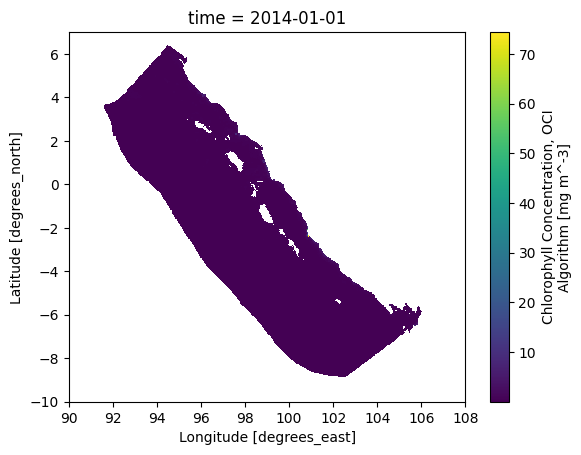

In [22]:
ds_hasil['chlor_a_3ddineof'].isel(time=0).plot()

In [23]:
ds_hasil

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 505, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time              (time) datetime64[ns] 4kB 2014-01-01 ... 2025-01-01
  * lat               (lat) float32 2kB 6.979 6.938 6.896 ... -9.938 -9.979
  * lon               (lon) float32 2kB 90.02 90.06 90.1 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a           (time, lat, lon) float32 356MB nan nan nan ... nan nan nan
    palette           (time, rgb, eightbitcolor) uint8 388kB ...
    mask_2d           (lat, lon) bool 176kB False False False ... False False
    chlor_a_3ddineof  (time, lat, lon) float64 712MB nan nan nan ... nan nan nan
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

In [24]:
print("💾 Memulai proses penyimpanan data...")

output_dir = "/kaggle/working"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# 1. SIMPAN df_missval KE CSV
# ============================================================
path_missval = os.path.join(output_dir, "df_missval.csv")

df_missval.to_csv(path_missval, index=False)

print(f"   ✅ df_missval berhasil disimpan ke CSV : {path_missval}")

# ============================================================
# 2. SIAPKAN ds_hasil UNTUK NETCDF
# ============================================================
ds_save = ds_hasil.copy()

# Buang mask_2d jika masih ada
if "mask_2d" in ds_save:
    ds_save = ds_save.drop_vars("mask_2d")
    print("   ✅ mask_2d dibuang dari ds_hasil.")

# Bersihkan atribut boolean pada semua variabel dan koordinat
for name in list(ds_save.data_vars) + list(ds_save.coords):
    for attr_name, attr_value in list(ds_save[name].attrs.items()):
        if isinstance(attr_value, (bool, np.bool_)):
            ds_save[name].attrs[attr_name] = int(attr_value)


# ============================================================
# 3. SIMPAN ds_hasil KE NETCDF
# ============================================================
path_dataset = os.path.join(output_dir, "ds_wpp_3d_clean.nc")

ds_save.to_netcdf(path_dataset)

print(f"   ✅ ds_hasil berhasil disimpan ke NetCDF : {path_dataset}")


# ============================================================
# 4. SIMPAN history KE PKL
# ============================================================
path_history = os.path.join(output_dir, "history_3d_dineof.pkl")

with open(path_history, "wb") as file_history:
    pickle.dump(history, file_history)

print(f"   ✅ history berhasil disimpan ke PKL : {path_history}")
print("\nDONE!!!")

💾 Memulai proses penyimpanan data...
   ✅ df_missval berhasil disimpan ke CSV : /kaggle/working/df_missval.csv
   ✅ mask_2d dibuang dari ds_hasil.
   ✅ ds_hasil berhasil disimpan ke NetCDF : /kaggle/working/ds_wpp_3d_clean.nc
   ✅ history berhasil disimpan ke PKL : /kaggle/working/history_3d_dineof.pkl

DONE!!!
